# 01 · Entrenamiento y evaluación (versión corregida)

Reemplaza a `Transfer_Learning_.ipynb`. La lógica está en `pipeline.py`; cada corrección lleva una etiqueta **[FIX-xx]** explicada en `diferencias_codigo.docx`.

**Principales correcciones**

| | Original | Corregido |
|---|---|---|
| Partición | aleatoria sobre 14.000 imágenes ya aumentadas | por imagen **original**, estratificada; test fijo sin aumentar |
| Augmentation | antes de partir (carpeta `data_aug7`) | al vuelo, **solo** en entrenamiento |
| Backbone | sin congelar en el código; un único objeto compartido | nuevo en cada experimento/trial/semilla, congelado (pesos **y** BatchNorm) |
| Optuna | el batch size sugerido no se usaba | los loaders se pasan a `fit()` |
| Evaluación | última época; F1 ponderado | mejor época en validación; test una vez; 5 semillas; métricas por clase, IC95% |

**Requisito de datos:** la carpeta con las 2.000 imágenes originales (`images_or`) y un CSV con una fila por imagen original (`nombre_imagen;label`, con la emoción en español tal como en `BDD7.csv`).

In [2]:
import os, sys

REPO = 'publicity_analysis'
if not os.path.exists(f'/content/{REPO}'):
    !git clone https://github.com/mlacarrasco/{REPO}.git /content/{REPO}
else:
    !git -C /content/{REPO} pull  # trae la última versión de pipeline.py

os.chdir(f'/content/{REPO}')
sys.path.insert(0, f'/content/{REPO}')
!pwd && ls

Cloning into '/content/publicity_analysis'...
remote: Enumerating objects: 2075, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2075 (delta 8), reused 14 (delta 5), pack-reused 2056 (from 1)
Receiving objects: 100% (2075/2075), 355.95 MiB | 30.19 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (2056/2056), done.
/content/publicity_analysis
01_entrenamiento.ipynb	etiquetas_originales.csv  pipeline.py  resultados
02_lime.ipynb		images_or		  __pycache__


In [3]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

import pipeline as pl

pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
!pip install numpy pandas torch torchvision pillow scipy scikit-learn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.2 MB/s eta 0:00:00


In [5]:
!pwd

/content/publicity_analysis


## 1. Configuración
Edite aquí las rutas. Todos los parámetros y su justificación están en `pl.Config`.

In [6]:
# En Colab los resultados se guardan en Google Drive: /content se borra al cortarse la sesión
# y así se puede retomar sin volver a entrenar lo que ya terminó.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/publicity_analysis/resultados'
except ImportError:
    OUTPUT_DIR = 'resultados'

cfg = pl.Config(
    originals_dir='images_or',
    labels_csv='etiquetas_originales.csv',
    output_dir=OUTPUT_DIR,
)
# Experimentos de la ablación (Tabla II) + variantes espaciales [FIX-05]
EXPERIMENTS = [1, 2, 3, 4, 5, 6, 7, 8, '4s', '8s']

os.makedirs(cfg.output_dir, exist_ok=True)
cfg.save(os.path.join(cfg.output_dir, 'config.json'))
print('Dispositivo:', cfg.device)
print('Resultados en:', cfg.output_dir)

Mounted at /content/drive
Dispositivo: cpu
Resultados en: /content/drive/MyDrive/publicity_analysis/resultados


## 2. Datos, distribución de clases y partición  [FIX-01, FIX-02]

In [7]:
df = pl.load_labels(cfg)
print(f'{len(df)} imágenes originales')
dist = pl.class_distribution(df)
dist.to_csv(os.path.join(cfg.output_dir, 'distribucion_clases.csv'), index=False)
dist

2000 imágenes originales


,valence,emotion,n,%
0,Positive,Curiosidad,168,8.400
1,Positive,Diversión,283,14.200
2,Positive,Felicidad,680,34.000
3,Neutral,Indiferencia,792,39.600
4,Negative,Desagrado,43,2.200
5,Negative,Miedo,23,1.200
6,Negative,Tristeza,11,0.600


In [8]:
splits0 = pl.make_splits(df, cfg, seed=cfg.seeds[0])
pl.save_manifest(splits0, os.path.join(cfg.output_dir, 'manifiestos', f'split_seed{cfg.seeds[0]}.csv'))
pl.split_distribution(splits0)

,train,val,test
Positive,792,169,170
Neutral,554,119,119
Negative,54,12,11


## 3. Baseline de clase mayoritaria

In [9]:
majority = pl.majority_baseline(df, cfg)
print(f"Clase mayoritaria: {majority['majority_class']}  |  accuracy={majority['accuracy']:.3f}  "
      f"balanced_acc={majority['balanced_accuracy']:.3f}  macro-F1={majority['macro_f1']:.3f}")

Clase mayoritaria: Positive  |  accuracy=0.567  balanced_acc=0.333  macro-F1=0.241


## 4. Parámetros entrenables y verificación del congelamiento  [FIX-03, FIX-04]
Tabla para la columna *Trainable params* de la Tabla II (pedido de R3). Se verifica además que un paso de entrenamiento no modifica ningún tensor del backbone (pesos ni estadísticas de BatchNorm).

In [10]:
rows = []
for exp in EXPERIMENTS + ['ft50']:
    m = pl.build_model(exp, cfg)
    trainable, total = pl.count_params(m)
    rows.append({'exp': exp, 'arch': pl.ARCH_OF_EXP[exp], 'trainable_params': trainable,
                 'total_params': total, 'backbone_frozen': m.freeze})
    del m
params_table = pd.DataFrame(rows)
params_table.to_csv(os.path.join(cfg.output_dir, 'parametros_modelos.csv'), index=False)
params_table

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:03<00:00, 75.6MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:02<00:00, 73.8MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 88.1MB/s]


,exp,arch,trainable_params,total_params,backbone_frozen
0,1,resnet152,6147,58149955,True
1,2,resnet152,525315,58669123,True
2,3,resnet152,591107,58734915,True
3,4,resnet152,623875,58767683,True
4,5,resnet152,689923,58833731,True
5,6,resnet152,755715,58899523,True
6,7,efficientnet_v2_m,3843,52862199,True
7,8,efficientnet_v2_m,427267,53285623,True
8,4s,resnet152,623875,58767683,True
9,8s,efficientnet_v2_m,427267,53285623,True


In [11]:
# Prueba: un paso de optimización no debe cambiar el backbone
m = pl.build_model(8, cfg)
fp = pl.backbone_fingerprint(m)
loader = pl.make_loader(splits0['train'], pl.ARCH_OF_EXP[8], cfg, batch_size=8, train=True)
x, y = next(iter(loader))
opt = pl.make_optimizer('Adam', [p for p in m.parameters() if p.requires_grad], 1e-3)
m.train()
loss = pl.F.cross_entropy(m(x.to(cfg.device)), y.to(cfg.device))
loss.backward()
opt.step()
print('Tensores del backbone modificados:', len(pl.changed_backbone_tensors(m, fp)))  # debe ser 0
del m

Tensores del backbone modificados: 0


## 5. Búsqueda de hiperparámetros con Optuna  [FIX-04, FIX-07, FIX-13]
Cada trial construye un modelo nuevo y usa el batch size sugerido. Métrica: `cfg.selection_metric` en validación. Los trials se guardan en `resultados/optuna/` (para rehacer la Fig. 5 como nube de puntos, sin interpolar). Si la sesión se corta, basta con volver a ejecutar las celdas: se retoma desde lo ya guardado en Drive.

In [12]:
# Se retoma automáticamente: los experimentos ya presentes en el JSON se saltan y los trials
# completados quedan en resultados/optuna/optuna.db (borrar ambos para rehacer la búsqueda).
bp_path = os.path.join(cfg.output_dir, 'mejores_hiperparametros.json')
best_params = {}
if os.path.exists(bp_path):
    with open(bp_path) as f:
        best_params = json.load(f)

for exp in EXPERIMENTS:
    if str(exp) in best_params:
        print(f'--- Optuna, experimento {exp}: ya terminado {best_params[str(exp)]} ---')
        continue
    print(f'--- Optuna, experimento {exp} ---')
    study = pl.run_optuna(exp, df, cfg)
    best_params[str(exp)] = study.best_params
    print(exp, study.best_params, f'val {cfg.selection_metric}={study.best_value:.4f}')
    with open(bp_path, 'w') as f:
        json.dump(best_params, f, indent=2)

--- Optuna, experimento 1: ya terminado {'lr': 0.004430375245218269, 'batch_size': 16, 'optimizer': 'SGD'} ---
--- Optuna, experimento 2: ya terminado {'lr': 0.016951482369182088, 'batch_size': 16, 'optimizer': 'SGD'} ---
--- Optuna, experimento 3: ya terminado {'lr': 0.018993830491860746, 'batch_size': 32, 'optimizer': 'SGD'} ---
--- Optuna, experimento 4: ya terminado {'lr': 0.03309440682225966, 'batch_size': 64, 'optimizer': 'SGD'} ---
--- Optuna, experimento 5: ya terminado {'lr': 0.00015401981068987325, 'batch_size': 16, 'optimizer': 'RMSprop'} ---
--- Optuna, experimento 6: ya terminado {'lr': 0.0002597459914786609, 'batch_size': 256, 'optimizer': 'RMSprop'} ---
--- Optuna, experimento 7: ya terminado {'lr': 0.03557963032521714, 'batch_size': 16, 'optimizer': 'Adam'} ---
--- Optuna, experimento 8: ya terminado {'lr': 0.016951482369182088, 'batch_size': 16, 'optimizer': 'SGD'} ---
--- Optuna, experimento 4s: ya terminado {'lr': 0.06823493012435795, 'batch_size': 128, 'optimizer': 

## 6. Entrenamiento final y evaluación en test  [FIX-10, FIX-11, FIX-12]
Para cada experimento y cada semilla: modelo nuevo → entrenamiento con early stopping sobre validación → evaluación **una vez** en el test fijo (originales sin aumentar). Se comprueba que el backbone no cambió. Cada semilla terminada se guarda en `modelos/result_exp*_seed*.json` y no se vuelve a entrenar.

In [13]:
results = []
for exp in EXPERIMENTS:
    print(f'--- Entrenamiento final, experimento {exp} ---')
    results += pl.run_final(exp, best_params[str(exp)], df, cfg)

pd.DataFrame(results).drop(columns='confusion_matrix').to_csv(
    os.path.join(cfg.output_dir, 'resultados_por_semilla.csv'), index=False)
with open(os.path.join(cfg.output_dir, 'resultados_por_semilla.json'), 'w') as f:
    json.dump(results, f, indent=2, default=float)

--- Entrenamiento final, experimento 1 ---
Experimento 1, semilla 0: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result_exp1_seed0.json
Experimento 1, semilla 1: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result_exp1_seed1.json
Experimento 1, semilla 2: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result_exp1_seed2.json
Experimento 1, semilla 3: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result_exp1_seed3.json
Experimento 1, semilla 4: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result_exp1_seed4.json
--- Entrenamiento final, experimento 2 ---
Experimento 2, semilla 0: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result_exp2_seed0.json
Experimento 2, semilla 1: ya entrenado, se carga /content/drive/MyDrive/publicity_analysis/resultados/modelos/result

## 7. Baselines  (R1: comparación con otros métodos)
- Features hand-crafted (color HSV, colorido, brillo, bordes, entropía) + SVM.
- ResNet-50 con *fine-tuning* completo (CNN estándar). Hiperparámetros fijos habituales para fine-tuning; cambie `RUN_FINETUNE` a `False` si no hay tiempo de GPU.

In [14]:
results += pl.run_svm_baseline(df, cfg)

RUN_FINETUNE = True
if RUN_FINETUNE:
    results += pl.run_final('ft50', {'lr': 1e-4, 'batch_size': 32, 'optimizer': 'Adam'}, df, cfg)

KeyboardInterrupt: 

## 7b. Linear probe sobre embeddings precalculados (CLIP, SigLIP, DINOv2)
El backbone está congelado, así que sus embeddings se calculan **una sola vez** (originales + `cfg.embedding_views` vistas con augmentation suave, sin flip vertical) y se guardan en `resultados/embeddings/`. Sobre ellos se entrena una regresión logística (`class_weight='balanced'`, C elegido por validación).

Se incluyen ResNet-152 y EfficientNet V2-M para comparar los backbones **con el mismo protocolo**. Hay dos evaluaciones:
1. **Protocolo de la Tabla III:** mismas particiones, semillas y test fijo que las CNN. Las filas `lp_*` se agregan a `results` y aparecen en la sección 8.
2. **CV estratificada repetida** (5×5) sobre las 2.000 imágenes. En cada repetición todas las imágenes, incluidas las 77 Negative, se predicen una vez fuera de pliegue, por lo que los IC95% son mucho más estables que con 11 Negative en test.


In [15]:
!pip install -q transformers

EMB_MODELS = ['clip_vitl14', 'siglip_so400m', 'dinov2_large', 'resnet152', 'efficientnet_v2_m']
embeddings = {k: pl.extract_embeddings(df, k, cfg) for k in EMB_MODELS}

clip_vitl14: embeddings cargados de /content/drive/MyDrive/publicity_analysis/resultados/embeddings/clip_vitl14_v4.npz
siglip_so400m: embeddings cargados de /content/drive/MyDrive/publicity_analysis/resultados/embeddings/siglip_so400m_v4.npz
dinov2_large: embeddings cargados de /content/drive/MyDrive/publicity_analysis/resultados/embeddings/dinov2_large_v4.npz
resnet152: embeddings cargados de /content/drive/MyDrive/publicity_analysis/resultados/embeddings/resnet152_v4.npz
efficientnet_v2_m: embeddings cargados de /content/drive/MyDrive/publicity_analysis/resultados/embeddings/efficientnet_v2_m_v4.npz


In [16]:
# 1) Protocolo de la Tabla III (test fijo)
for k in EMB_MODELS:
    results += pl.run_embedding_final(k, embeddings[k], df, cfg)
pl.summarize([r for r in results if r['exp'].startswith('lp_')])[
    ['exp', 'n_seeds', 'accuracy', 'balanced_accuracy', 'macro_f1', 'macro_f1_ci95',
     'f1_Positive', 'f1_Neutral', 'f1_Negative']]

KeyboardInterrupt: 

In [15]:
# 2) CV estratificada repetida sobre las 2.000 imágenes
cv_results = []
for k in EMB_MODELS:
    cv_results += pl.run_embedding_cv(k, embeddings[k], df, cfg)
cv_summary = pl.summarize(cv_results).rename(columns={'n_seeds': 'n_repeats'})
cv_summary.to_csv(os.path.join(cfg.output_dir, 'tabla_linear_probe_cv.csv'), index=False)
cv_summary[['exp', 'n_repeats', 'accuracy', 'balanced_accuracy', 'macro_f1', 'macro_f1_ci95',
            'f1_Positive', 'f1_Neutral', 'f1_Negative', 'f1_Negative_ci95']]

clip_vitl14, repetición 0: macro-F1=0.516  acc=0.635
clip_vitl14, repetición 1: macro-F1=0.511  acc=0.627
clip_vitl14, repetición 2: macro-F1=0.503  acc=0.612
clip_vitl14, repetición 3: macro-F1=0.501  acc=0.620
clip_vitl14, repetición 4: macro-F1=0.518  acc=0.634
siglip_so400m, repetición 0: macro-F1=0.509  acc=0.617
siglip_so400m, repetición 1: macro-F1=0.501  acc=0.623
siglip_so400m, repetición 2: macro-F1=0.493  acc=0.620
siglip_so400m, repetición 3: macro-F1=0.485  acc=0.607
siglip_so400m, repetición 4: macro-F1=0.505  acc=0.623
dinov2_large, repetición 0: macro-F1=0.482  acc=0.619
dinov2_large, repetición 1: macro-F1=0.492  acc=0.619
dinov2_large, repetición 2: macro-F1=0.489  acc=0.616
dinov2_large, repetición 3: macro-F1=0.489  acc=0.610
dinov2_large, repetición 4: macro-F1=0.505  acc=0.635
resnet152, repetición 0: macro-F1=0.436  acc=0.572
resnet152, repetición 1: macro-F1=0.444  acc=0.575
resnet152, repetición 2: macro-F1=0.439  acc=0.585
resnet152, repetición 3: macro-F1=0.4

,exp,n_repeats,accuracy,balanced_accuracy,macro_f1,macro_f1_ci95,f1_Positive,f1_Neutral,f1_Negative,f1_Negative_ci95
0,lp_clip_vitl14,5,0.626,0.532,0.510,"[0.500, 0.519]",0.690,0.587,0.253,"[0.239, 0.268]"
1,lp_siglip_so400m,5,0.618,0.515,0.499,"[0.487, 0.510]",0.681,0.578,0.238,"[0.210, 0.266]"
2,lp_dinov2_large,5,0.620,0.503,0.491,"[0.481, 0.502]",0.688,0.572,0.214,"[0.192, 0.237]"
3,lp_resnet152,5,0.576,0.458,0.440,"[0.436, 0.444]",0.658,0.538,0.125,"[0.111, 0.139]"
4,lp_efficientnet_v2_m,5,0.591,0.472,0.455,"[0.441, 0.469]",0.667,0.553,0.146,"[0.120, 0.172]"


In [17]:
# Matriz de confusión (sumada sobre repeticiones) del mejor modelo en CV
best_cv = cv_summary.sort_values('macro_f1').iloc[-1]['exp']
pl.plot_confusion(pl.aggregate_confusion(cv_results, best_cv), title=f'{best_cv} (CV 5×5)')
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'matriz_confusion_linear_probe_cv.png'), dpi=200)
plt.show()

NameError: name 'cv_summary' is not defined

## 8. Tabla III nueva: test, media ± DE e IC95% sobre semillas

In [15]:
summary = pl.summarize(results)
maj_row = {'exp': 'majority', 'arch': '-', 'n_seeds': 1,
           **{k: majority[k] for k in ['accuracy', 'balanced_accuracy', 'macro_f1',
                                       'f1_Positive', 'f1_Neutral', 'f1_Negative']}}
summary = pd.concat([pd.DataFrame([maj_row]), summary], ignore_index=True)
summary.to_csv(os.path.join(cfg.output_dir, 'tabla_III_test.csv'), index=False)
summary[['exp', 'arch', 'n_seeds', 'accuracy', 'accuracy_sd', 'accuracy_ci95',
         'balanced_accuracy', 'macro_f1', 'macro_f1_ci95', 'f1_Positive', 'f1_Neutral', 'f1_Negative']]

,exp,arch,n_seeds,accuracy,accuracy_sd,accuracy_ci95,balanced_accuracy,macro_f1,macro_f1_ci95,f1_Positive,f1_Neutral,f1_Negative
0,majority,-,1,0.567,NaN,NaN,0.333,0.241,NaN,0.723,0.000,0.000
1,1,resnet152,5,0.577,0.028,"[0.542, 0.611]",0.492,0.450,"[0.416, 0.483]",0.643,0.559,0.147
2,2,resnet152,5,0.600,0.026,"[0.568, 0.632]",0.498,0.477,"[0.453, 0.502]",0.658,0.576,0.197
3,3,resnet152,5,0.611,0.016,"[0.591, 0.632]",0.475,0.462,"[0.433, 0.491]",0.692,0.551,0.142
4,4,resnet152,5,0.590,0.044,"[0.535, 0.645]",0.500,0.469,"[0.418, 0.520]",0.663,0.568,0.175
5,5,resnet152,5,0.595,0.022,"[0.567, 0.622]",0.503,0.468,"[0.441, 0.496]",0.667,0.565,0.174
6,6,resnet152,5,0.597,0.023,"[0.568, 0.626]",0.474,0.452,"[0.432, 0.472]",0.673,0.559,0.125
7,7,efficientnet_v2_m,5,0.586,0.044,"[0.531, 0.641]",0.429,0.427,"[0.367, 0.488]",0.655,0.537,0.089
8,8,efficientnet_v2_m,5,0.619,0.021,"[0.593, 0.645]",0.469,0.464,"[0.439, 0.490]",0.693,0.571,0.130
9,4s,resnet152,5,0.575,0.036,"[0.529, 0.620]",0.500,0.454,"[0.426, 0.481]",0.664,0.532,0.165


## 9. Matrices de confusión (sumadas sobre semillas)  [R3, R4]

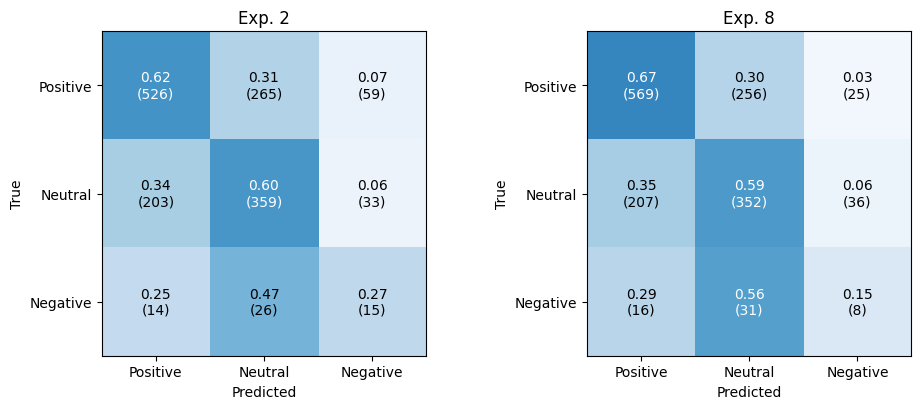

In [16]:
best_resnet = summary[summary.arch == 'resnet152'].sort_values('macro_f1').iloc[-1]['exp']
best_effnet = summary[summary.arch == 'efficientnet_v2_m'].sort_values('macro_f1').iloc[-1]['exp']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, exp in zip(axes, [best_resnet, best_effnet]):
    pl.plot_confusion(pl.aggregate_confusion(results, exp), title=f'Exp. {exp}', ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'matrices_confusion.png'), dpi=200)
plt.show()

## 10. Entorno de hardware y software  [R1, R3]

In [17]:
info = pl.env_info()
with open(os.path.join(cfg.output_dir, 'entorno.json'), 'w') as f:
    json.dump(info, f, indent=2)
info

{'python': '3.13.15',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'torch': '2.11.0+cu130',
 'cuda_available': True,
 'cuda': '13.0',
 'cudnn': 92700,
 'torchvision': '0.26.0+cu130',
 'optuna': '5.0.0',
 'lime': None,
 'scikit-image': '0.25.2',
 'scikit-learn': '1.6.1',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'gpu_memory_gb': 79.3,
 'ram_gb': 167.1}

In [33]:
!git -C /content/publicity_analysis pull

Already up to date.
